In [1]:
# ⚙️ Parameters — change these and re-run
REFERENCE_DATE = "2020-02-21"
DATE = "2021-02-21"
PORTFOLIO = "60/40 Multi-Asset"
ESTIMATION_WINDOW = 252
VOLATILITY_DISPLAY_WINDOW = 252


In [2]:
import sys
from pathlib import Path

# Locate the project root from either the project root or this notebook's directory.
current_directory = Path.cwd().resolve()
project_root = next(
    path for path in (current_directory, *current_directory.parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import Markdown, display
from src.display.attribution_renderer import render_attribution_markdown
from src.display.attribution_change_renderer import render_attribution_change_markdown
from src.display.portfolio_risk_renderer import (
    plot_rolling_portfolio_volatility,
    render_portfolio_risk_markdown,
)
from src.engine.attribution_engine import AttributionEngine
from src.engine.attribution_comparison_engine import AttributionComparisonEngine
from src.engine.portfolio_risk_engine import PortfolioRiskEngine
from src.infrastructure.in_memory_portfolios import InMemoryPortfolioRepository
from src.infrastructure.yfinance_returns import YFinanceReturnsProvider

# Composition root — portfolio risk and asset decomposition share concrete data dependencies.
portfolios = InMemoryPortfolioRepository()
returns_provider = YFinanceReturnsProvider()

portfolio_risk_engine = PortfolioRiskEngine(
    portfolios=portfolios,
    returns_provider=returns_provider,
)
attribution_engine = AttributionEngine(
    portfolios=portfolios,
    returns_provider=returns_provider,
)
attribution_comparison_engine = AttributionComparisonEngine()


## Portfolio risk

**60/40 Multi-Asset**<br>
As of 21 February 2021<br>

**Current daily volatility:** 1.22%<br>
Latest calculated observation: 19 February 2021<br>
Previous daily volatility (19 January 2021): 1.21%<br>
Change since previous month: +0.01 percentage points

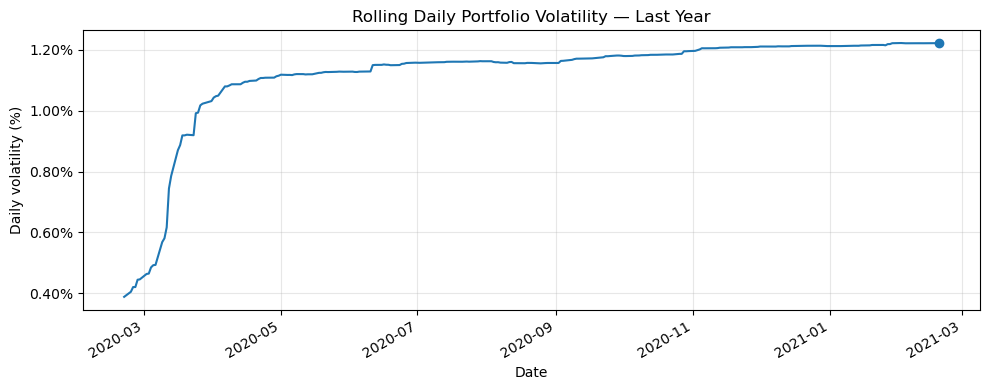

In [3]:
portfolio_risk = portfolio_risk_engine.calculate(
    portfolio_name=PORTFOLIO,
    date=DATE,
    estimation_window=ESTIMATION_WINDOW,
    display_window=VOLATILITY_DISPLAY_WINDOW,
)

display(Markdown(render_portfolio_risk_markdown(
    portfolio_risk,
    portfolio_name=PORTFOLIO,
    requested_date=DATE,
)))

_portfolio_risk_figure = plot_rolling_portfolio_volatility(
    portfolio_risk.volatility_history,
    portfolio_name=PORTFOLIO,
    requested_date=DATE,
)


In [4]:
attribution = attribution_engine.attribute(
    portfolio_name=PORTFOLIO,
    date=DATE,
    estimation_window=ESTIMATION_WINDOW,
)

display(Markdown(render_attribution_markdown(
    attribution,
    portfolio_name=PORTFOLIO,
    date=DATE,
    estimation_window=ESTIMATION_WINDOW,
)))


**ATTRIBUTION**<br><br>**60/40 Multi-Asset**<br>As of 21 February 2021<br><br>**Where does risk live?**<br><br>Ranked by signed contribution to portfolio risk.<br><br>

| Asset | Weight | Portfolio risk contribution | % | Cumulative risk contribution |
|---|---:|:---|---:|---:|
| SPY | 40% | █████████████ | 67% | 67% |
| EFA | 20% | ██████ | 31% | 98% |
| GLD | 15% | █ | 5% | 103% |
| IEF | 25% | ◄ | -3% | 100% |



In [5]:
# ── Code cell 5 ──
reference_attribution = attribution_engine.attribute(
    portfolio_name=PORTFOLIO,
    date=REFERENCE_DATE,
    estimation_window=ESTIMATION_WINDOW,
)

attribution_change = attribution_comparison_engine.compare(
    reference_attribution=reference_attribution,
    current_attribution=attribution,
)

display(Markdown(render_attribution_change_markdown(
    attribution_change,
    portfolio_name=PORTFOLIO,
)))


**CONTRIBUTION CHANGE**<br><br>**60/40 Multi-Asset**<br>Reference as of 20 February 2020<br>Current as of 19 February 2021<br><br>**How has risk contribution changed?**<br><br>

| Asset | Reference contribution % | Current contribution % | Change, percentage points |
|---|---:|---:|---:|
| GLD | 4% | 5% | +1.82 pp |
| SPY | 68% | 67% | -1.14 pp |
| IEF | -3% | -3% | -0.41 pp |
| EFA | 31% | 31% | -0.27 pp |



The chart shows the rolling standard deviation of daily portfolio returns.<br>
Each estimate uses the trailing 252 daily returns and the current portfolio weights.<br>
The series is not annualised and does not represent the realised volatility of historical portfolio holdings.
